In [84]:
import torch
from PIL import Image, ImageDraw
import numpy as np

In [85]:
# Model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in /home/binghao/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-4-5 Python-3.10.12 torch-2.2.2+cu121 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [86]:
img = Image.open("../assets/cat_dog.jpg")

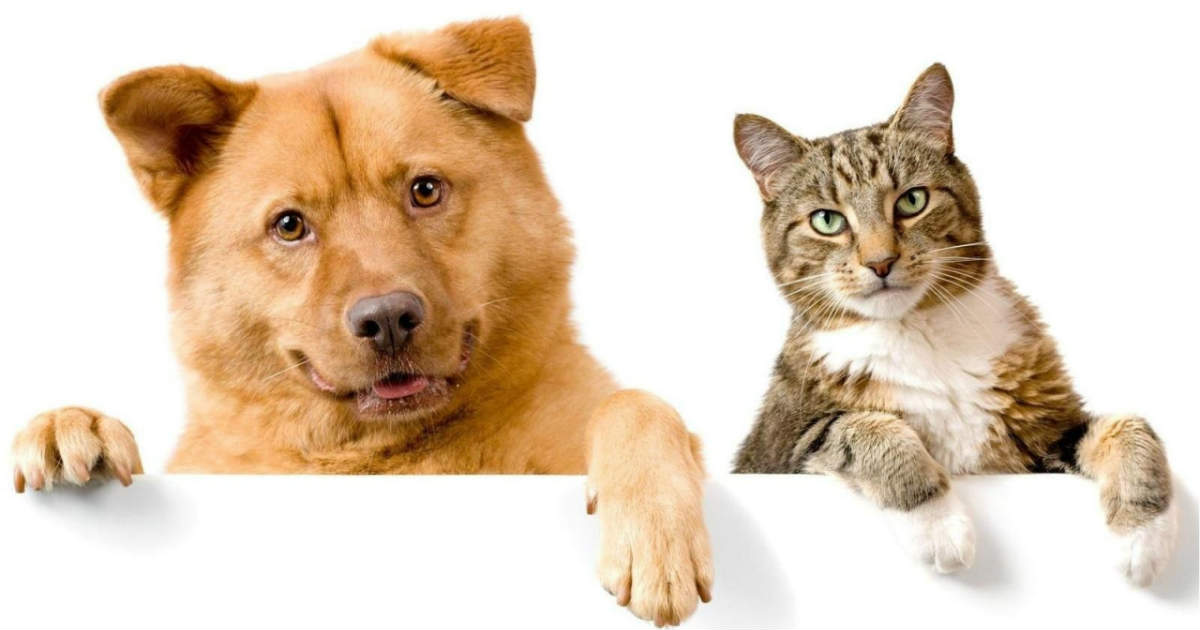

In [87]:
img

In [88]:
results = model([img])

In [89]:
res = results.pandas().xyxy

In [90]:
res

[         xmin       ymin         xmax        ymax  confidence  class name
 0  729.289490  61.938828  1172.989502  588.544678    0.857626     15  cat
 1   81.639458  11.179561   735.695557  620.677856    0.697073     16  dog]

In [92]:
res[0].to_dict(orient="records")

[{'xmin': 729.2894897460938,
  'ymin': 61.93882751464844,
  'xmax': 1172.989501953125,
  'ymax': 588.544677734375,
  'confidence': 0.8576256036758423,
  'class': 15,
  'name': 'cat'},
 {'xmin': 81.63945770263672,
  'ymin': 11.179560661315918,
  'xmax': 735.695556640625,
  'ymax': 620.6778564453125,
  'confidence': 0.697073221206665,
  'class': 16,
  'name': 'dog'}]

In [ ]:
res.name.values[0]

'cat'

In [ ]:
annotated_img = ImageDraw.Draw(img)
annotated_img.rectangle([(res.xmin, res.ymin), (res.xmax, res.ymax)], outline="black", width=2)
annotated_img.text((res.xmin, res.ymin), res.name.values[0], fill="black")


/home/binghao/projects/python-grpc-ml-demo/.devenv/lib/python3.10/site-packages/PIL/ImageDraw.py:305: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  self.draw.draw_rectangle(xy, ink, 0, width)
/home/binghao/projects/python-grpc-ml-demo/.devenv/lib/python3.10/site-packages/PIL/ImageDraw.py:507: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  coord.append(int(xy[i]))
/home/binghao/projects/python-grpc-ml-demo/.devenv/lib/python3.10/site-packages/PIL/ImageDraw.py:508: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start.append(math.modf(xy[i])[0])


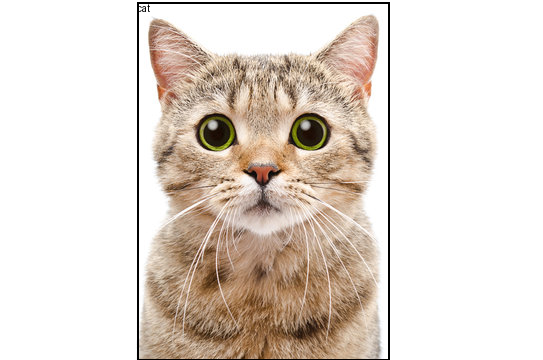

In [ ]:
img

import cv2
from PIL import Image

cap = cv2.VideoCapture(0)   # /dev/video0
while True:
  ret, frame = cap.read()
  if not ret:
    break
  pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))